# Registry Inspection
Notebook used for inspecting the registry structure (from Data Dictionary as MD source, and export_long_clean for exported data source)

In [163]:
# Imports
from pathlib import Path

import pandas as pd

In [164]:
# Paths


PROJECT_ROOT = Path.cwd()
DATA_DICTIONARY_PATH = (
    PROJECT_ROOT
    / "metadata"
    / "processed"
    / "data_dictionary.csv"
)

EXPORT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "export_long_clean.csv"
)

OUTPUT_PATH = PROJECT_ROOT /"results"/"inspection"

In [165]:
# Loads
data_dictionary = pd.read_csv(
    DATA_DICTIONARY_PATH,
    sep=";",
    dtype=object
)

export_long = pd.read_csv(
    EXPORT_PATH,
    sep=";",
    dtype=object
)

In [166]:
print("Data dictionary shape:", data_dictionary.shape)
print("Export shape:", export_long.shape)

Data dictionary shape: (460, 17)
Export shape: (247704, 6)


## Metadata Inspection

In [167]:
data_dictionary.head()

,Form,form_id,form_type,record_urn,record_designation,record_mandatory,record_repeatable,dataelement_urn,dataelement_designation,dataelement_definition,dataelement_mandatory,dataelement_repeatable,data_type,data_format,unit,source_id,slots
0,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:42:1,Center,Name of the participating center,true,false,STRING,NaN,NaN,X_222_0_42,NaN
1,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:43:2,Patient ID,Patient's identification number of ACLF-I (sho...,true,false,STRING,NaN,NaN,X_222_0_43,NaN
2,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:46:1,Inclusion criteria,Inclusion criteria,true,false,enumerated,enumerated,NaN,X_222_0_46,SELECT_MANY_CHECKBOX
3,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:45:1,Exclusion criteria,Exclusion criteria,false,false,enumerated,enumerated,NaN,X_222_0_45,SELECT_MANY_CHECKBOX
4,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:345:1,Responsible Doctor,Name of the Doctor or investigator responsible...,true,false,STRING,NaN,NaN,X_222_0_345,NaN


In [168]:
print("Data dictionary columns:")
print(data_dictionary.columns.tolist())



Data dictionary columns:
['Form', 'form_id', 'form_type', 'record_urn', 'record_designation', 'record_mandatory', 'record_repeatable', 'dataelement_urn', 'dataelement_designation', 'dataelement_definition', 'dataelement_mandatory', 'dataelement_repeatable', 'data_type', 'data_format', 'unit', 'source_id', 'slots']


In [169]:
len(data_dictionary)

460

In [170]:
data_dictionary["source_id"].nunique()

460

The length of the DD and the amount of unique source_ids confirms that the dictionary does not contain repeated source_id entries

In [171]:
data_dictionary["dataelement_urn"].nunique()

323

More unique source_ids than unique element URNs means some elements are present in multiple instances

In [172]:
repeated_urns = data_dictionary[data_dictionary.duplicated(subset=["dataelement_urn"],keep=False)]

repeated_urns

repeated_urns_subset = repeated_urns[["dataelement_urn", "source_id"]].sort_values(["dataelement_urn", "source_id"])
repeated_urns_subset


,dataelement_urn,source_id
67,urn:osse-11:dataelement:109:1,X_226_0_109
165,urn:osse-11:dataelement:109:1,X_228_0_109
69,urn:osse-11:dataelement:111:1,X_226_0_111
167,urn:osse-11:dataelement:111:1,X_228_0_111
66,urn:osse-11:dataelement:112:1,X_226_0_112
...,...,...
229,urn:osse-11:dataelement:85:1,X_230_0_85
44,urn:osse-11:dataelement:88:1,X_224_0_88
428,urn:osse-11:dataelement:88:1,X_235_0_88
47,urn:osse-11:dataelement:91:1,X_224_0_91


### Data Type distribution


In [173]:
data_dictionary_unique = data_dictionary.drop_duplicates(
    subset=["source_id"]
) # not counting repeated elements

data_dictionary_unique["data_type"].value_counts(dropna=False)


data_type
enumerated    261
FLOAT          82
INTEGER        56
STRING         30
DATE           22
BOOLEAN         7
DATETIME        1
TIME            1
Name: count, dtype: int64

In [174]:
datatype_summary = (
    data_dictionary
    .drop_duplicates(subset=["dataelement_urn"])
    .groupby("data_type", dropna=False)
    .size()
    .reset_index(name="n_elements")
    .sort_values("n_elements", ascending=False)
)

datatype_summary

,data_type,n_elements
7,enumerated,176
3,FLOAT,58
4,INTEGER,37
5,STRING,25
1,DATE,19
0,BOOLEAN,6
2,DATETIME,1
6,TIME,1


In [175]:
datatype_summary.to_csv(OUTPUT_PATH/"datatype_summary.csv", sep=";")

In [176]:
datatype_summary["percentage"] = (
    datatype_summary["n_elements"]
    / datatype_summary["n_elements"].sum()
    * 100
).round(1)

datatype_summary

,data_type,n_elements,percentage
7,enumerated,176,54.5
3,FLOAT,58,18.0
4,INTEGER,37,11.5
5,STRING,25,7.7
1,DATE,19,5.9
0,BOOLEAN,6,1.9
2,DATETIME,1,0.3
6,TIME,1,0.3


### Data formats within each type


In [177]:
(
    data_dictionary[
        ["data_type", "data_format"]
    ]
    .drop_duplicates()
    .sort_values(["data_type", "data_format"])
)

,data_type,data_format
14,BOOLEAN,(true|false|yes|no|f|t)
6,DATE,DD.MM.YYYY
57,DATE,MM.YYYY
264,DATE,YYYY-MM-DD
436,DATETIME,DD.MM.YYYY hh:mm
43,FLOAT,0<=x
16,FLOAT,0<=x<=100
250,FLOAT,0<=x<=10000
270,FLOAT,0<=x<=14
11,FLOAT,0<=x<=200


In [178]:
datatype_summary.to_csv(OUTPUT_PATH/"datatype_summary.csv", sep=";")

In [179]:
datatype_dataformat_summary = (
    data_dictionary
    .drop_duplicates(subset=["dataelement_urn"])
    .groupby(
        ["data_type", "data_format"],
        dropna=False
    )
    .size()
    .reset_index(name="n_elements")
    .sort_values(
        ["data_type", "n_elements"],
        ascending=[True, False]
    )
)

datatype_dataformat_summary

,data_type,data_format,n_elements
0,BOOLEAN,(true|false|yes|no|f|t),6
1,DATE,DD.MM.YYYY,17
2,DATE,MM.YYYY,1
3,DATE,YYYY-MM-DD,1
4,DATETIME,DD.MM.YYYY hh:mm,1
5,FLOAT,0<=x,31
6,FLOAT,0<=x<=100,13
9,FLOAT,0<=x<=200,3
8,FLOAT,0<=x<=14,2
10,FLOAT,0<=x<=300,2


In [180]:
datatype_dataformat_summary.to_csv(OUTPUT_PATH/"datatype_dataformat_summary.csv", sep=";")

In [181]:
## slots in enumerated types

In [182]:
enumerated = data_dictionary.loc[data_dictionary["data_type"]=="enumerated"]
enumerated

,Form,form_id,form_type,record_urn,record_designation,record_mandatory,record_repeatable,dataelement_urn,dataelement_designation,dataelement_definition,dataelement_mandatory,dataelement_repeatable,data_type,data_format,unit,source_id,slots
2,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:46:1,Inclusion criteria,Inclusion criteria,true,false,enumerated,enumerated,NaN,X_222_0_46,SELECT_MANY_CHECKBOX
3,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:45:1,Exclusion criteria,Exclusion criteria,false,false,enumerated,enumerated,NaN,X_222_0_45,SELECT_MANY_CHECKBOX
5,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:47:1,Informed consent signed:,Informed consent signed:,true,false,enumerated,enumerated,NaN,X_222_0_47,SELECT_ONE_RADIO
7,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:49:2,Informed consent permission granted:,Informed consent permission granted:,false,false,enumerated,enumerated,NaN,X_222_0_49,SELECT_MANY_CHECKBOX
8,Screen data,222:8,Basic,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:50:1,If Informed consent is signed by surrogate:,- Research study under prior surrogate consent,false,false,enumerated,enumerated,NaN,X_222_0_50,SELECT_ONE_RADIO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,Status,236:2,Longitudinal,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:8:1,Status,Patient's status,false,false,enumerated,enumerated,NaN,X_236_0_8,SELECT_ONE_RADIO
453,Status,236:2,Longitudinal,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:338:1,Patient's vital status,Patient's vital status,true,false,enumerated,enumerated,NaN,X_236_0_338,SELECT_ONE_RADIO
455,Status,236:2,Longitudinal,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:340:1,In-hospital death,In-hospital death,false,false,enumerated,enumerated,NaN,X_236_0_340,SELECT_ONE_RADIO
456,Status,236:2,Longitudinal,NaN,NaN,NaN,NaN,urn:osse-11:dataelement:341:1,Cause(s) of death,Cause(s) of death,false,false,enumerated,enumerated,NaN,X_236_0_341,SELECT_MANY_CHECKBOX


In [183]:
enumerated_summary = (
    enumerated
    .drop_duplicates(subset=["dataelement_urn"])
    .groupby(
        ["data_type", "slots"],
        dropna=False
    )
    .size()
    .reset_index(name="n_elements")
    .sort_values(
        ["data_type", "n_elements"],
        ascending=[True, False]
    )
)

enumerated_summary

,data_type,slots,n_elements
1,enumerated,SELECT_ONE_RADIO,139
0,enumerated,SELECT_MANY_CHECKBOX,36
2,enumerated,NaN,1


In [184]:
dates = data_dictionary.loc[data_dictionary["data_type"]=="DATE"]
dates


dates_summary = (
    dates
    .drop_duplicates(subset=["dataelement_urn"])
    .groupby(
        ["data_type", "data_format"],
        dropna=False
    )
    .size()
    .reset_index(name="n_elements")
    .sort_values(
        ["data_type", "n_elements"],
        ascending=[True, False]
    )
)

dates_summary

,data_type,data_format,n_elements
0,DATE,DD.MM.YYYY,17
1,DATE,MM.YYYY,1
2,DATE,YYYY-MM-DD,1


In [206]:
float = data_dictionary.loc[data_dictionary["data_type"]=="INTEGER"]
float


float_summary = (
    float
    .drop_duplicates(subset=["dataelement_urn"])
    .groupby(
        ["data_type", "data_format"],
        dropna=False
    )
    .size()
    .reset_index(name="n_elements")
    .sort_values(
        ["data_type", "n_elements"],
        ascending=[True, False]
    )
)

float_summary

,data_type,data_format,n_elements
2,INTEGER,0<=x<=100,11
5,INTEGER,0<=x<=200,5
7,INTEGER,0<=x<=3,5
3,INTEGER,0<=x<=1000,3
4,INTEGER,0<=x<=20,3
8,INTEGER,0<=x<=300,3
0,INTEGER,0<=x,2
1,INTEGER,0<=x<=10,1
6,INTEGER,0<=x<=20000,1
9,INTEGER,0<=x<=6,1


## Form Inspection

In [185]:
n_forms = data_dictionary["form_id"].nunique()

print(f"Number of forms: {n_forms}")

Number of forms: 15


In [186]:
forms_unique = (
    data_dictionary[
        ["form_id", "Form", "form_type"]
    ]
    .drop_duplicates(subset=["form_id"])
)

forms_unique

,form_id,Form,form_type
0,222:8,Screen data,Basic
10,224:4,ACLF evaluation,Basic
48,225:2,Patient’s information and Medical history,Basic
66,226:11,Previous clinical course,Basic
98,227:3,Previous treatments,Basic
158,228:9,Data at visit,Longitudinal
174,229:3,Clinical features,Longitudinal
205,230:9,Physical examination,Longitudinal
230,231:12,Laboratory data 1,Longitudinal
268,232:6,Laboratory data 2,Longitudinal


In [187]:
form_type_summary = (
    forms_unique
    .groupby("form_type", dropna=False)
    .size()
    .reset_index(name="n_forms")
    .sort_values("n_forms", ascending=False)
)

form_type_summary

,form_type,n_forms
1,Longitudinal,10
0,Basic,5


In [188]:
## elements per form
elements_per_form = (
    data_dictionary
    .groupby(
        ["form_id", "Form", "form_type"],
        dropna=False
    )["source_id"]
    .nunique()
    .reset_index(name="n_elements")
    .sort_values("n_elements", ascending=False)
)

elements_per_form

elements_per_form.to_csv(OUTPUT_PATH/"elements_per_form.csv", sep=";")

## Export inspection

In [189]:
export_long.head()

,PID,Episode,Episode_Date,IX,source_id,source_value
0,10,basic,NaN,1,X_222_0_42,Frankfurt University Hospital
1,100,basic,NaN,1,X_222_0_42,GUF
2,101,basic,NaN,1,X_222_0_42,GUF
3,102,basic,NaN,1,X_222_0_42,GUF
4,103,basic,NaN,1,X_222_0_42,GUF


In [190]:
print("\nExport columns:")
print(export_long.columns.tolist())


Export columns:
['PID', 'Episode', 'Episode_Date', 'IX', 'source_id', 'source_value']


In [191]:
n_patients = export_long["PID"].nunique()

print(f"Number of patients: {n_patients:,}")

Number of patients: 266


In [210]:
n_episodes = (
    export_long
    .dropna(subset=["PID", "Episode_Date"])
    [["PID", "Episode_Date"]]
    .drop_duplicates()
    .shape[0]
)

print(f"Number of unique patient episodes: {n_episodes:,}")

Number of unique patient episodes: 419


In [211]:
episodes_per_patient = (
    export_long
    .dropna(subset=["PID", "Episode_Date"])
    [["PID", "Episode_Date"]]
    .drop_duplicates()
    .groupby("PID")
    .size()
    .rename("n_episodes")
)

episodes_per_patient.head()

PID
10     1
100    2
101    2
102    2
103    1
Name: n_episodes, dtype: int64

In [212]:
episode_distribution = (
    episodes_per_patient
    .value_counts()
    .sort_index()
    .rename_axis("Episodes per patient")
    .reset_index(name="Number of patients")
)

episode_distribution

,Episodes per patient,Number of patients
0,1,167
1,2,58
2,3,25
3,4,6
4,5,3
5,6,1
6,7,1
7,9,1


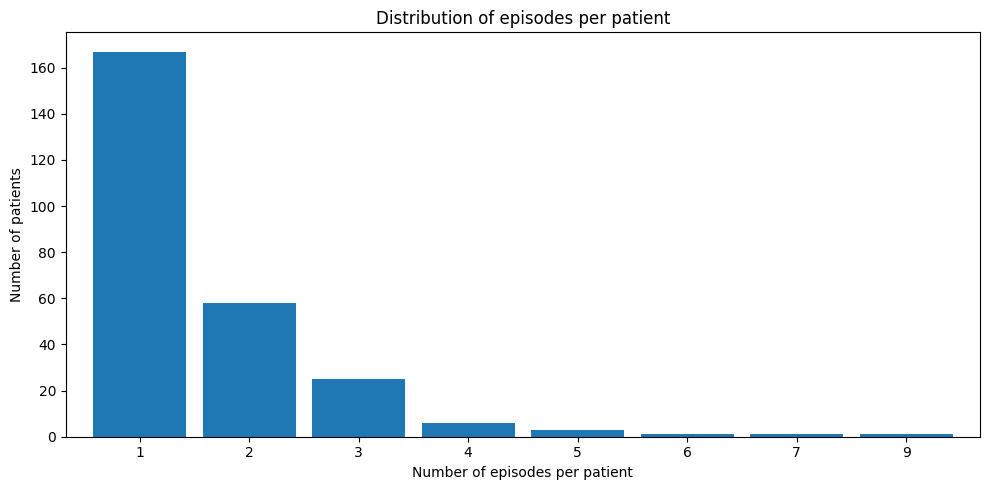

In [216]:
import matplotlib.pyplot as plt

episode_distribution.plot(
    x="Episodes per patient",
    y="Number of patients",
    kind="bar",
    legend=False,
    figsize=(10, 5),
        width=0.85
)

plt.xlabel("Number of episodes per patient")
plt.ylabel("Number of patients")
plt.title("Distribution of episodes per patient")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [214]:
episodes_per_patient.describe()

count    262.000000
mean       1.599237
std        1.055763
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        9.000000
Name: n_episodes, dtype: float64

In [192]:
n_missing_patient_ids = export_long["PID"].isna().sum()

print(f"Rows with missing patient ID: {n_missing_patient_ids:,}")

Rows with missing patient ID: 0


In [193]:
n_export_rows = len(export_long)

print(f"Total rows in the long export: {n_export_rows:,}")

Total rows in the long export: 247,704


In [194]:
n_exported_variables = export_long["source_id"].nunique()

print(f"Unique source IDs present in the export: {n_exported_variables:,}")

Unique source IDs present in the export: 451


# Inspection of whether all elements in export match to DD

In [217]:
export_elements = set(
    export_long["source_id"]
    .dropna()
    .astype(str)
    .str.strip()
)

dictionary_elements = set(
    data_dictionary["source_id"]
    .dropna()
    .astype(str)
    .str.strip()
)

missing_from_dictionary = export_elements - dictionary_elements

print(f"Unique elements in export: {len(export_elements):,}")
print(f"Unique elements in data dictionary: {len(dictionary_elements):,}")
print(f"Export elements missing from data dictionary: {len(missing_from_dictionary):,}")

Unique elements in export: 451
Unique elements in data dictionary: 460
Export elements missing from data dictionary: 0


## Record inspection

data_dictionary["record_urn"].isna().value_counts()

In [195]:
n_records = data_dictionary["record_urn"].nunique()

print(f"Total unique records: {n_records}")

Total unique records: 54


In [196]:
data_dictionary["record_urn"].isna().value_counts()

record_urn
False    244
True     216
Name: count, dtype: int64

In [197]:
records_unique = (
    data_dictionary[
        [
            "record_urn",
            "record_designation",
            "record_mandatory",
            "record_repeatable"
        ]
    ]
    .dropna(subset=["record_urn"])
    .drop_duplicates(subset=["record_urn"])
    .sort_values("record_urn")
)

records_unique

,record_urn,record_designation,record_mandatory,record_repeatable
450,urn:osse-11:record:10:1,Hair sample collection information,false,false
10,urn:osse-11:record:16:1,Liver failure,false,false
12,urn:osse-11:record:17:1,Renal failure,false,false
15,urn:osse-11:record:18:1,Coagulation failure,false,false
19,urn:osse-11:record:19:1,Circulatory failure,false,false
24,urn:osse-11:record:20:1,Respiratory failure,false,false
50,urn:osse-11:record:21:1,Tobacco consumption,false,false
54,urn:osse-11:record:22:1,Diagnosis of Cirrhosis,false,false
64,urn:osse-11:record:23:1,Other previous /concomitant medical disease,false,false
71,urn:osse-11:record:25:1,Prior ascites,false,false


In [198]:
records_per_form = (
    data_dictionary
    .dropna(subset=["record_urn"])
    .groupby(
        ["form_id", "Form", "form_type"],
        dropna=False
    )["record_urn"]
    .nunique()
    .reset_index(name="n_records")
    .sort_values("n_records", ascending=False)
)

records_per_form

,form_id,Form,form_type,n_records
4,227:3,Previous treatments,Basic,16
7,233:10,Treatment,Longitudinal,15
8,235:7,Scores,Longitudinal,11
6,229:3,Clinical features,Longitudinal,6
3,226:11,Previous clinical course,Basic,6
0,223:3,Biobank sample collection,Longitudinal,5
1,224:4,ACLF evaluation,Basic,5
2,225:2,Patient’s information and Medical history,Basic,3
5,228:9,Data at visit,Longitudinal,1


In [199]:
records_per_form = (
    forms_unique
    .merge(
        records_per_form,
        on=["form_id", "Form", "form_type"],
        how="left"
    )
)

records_per_form["n_records"] = (
    records_per_form["n_records"]
    .fillna(0)
    .astype(int)
)

records_per_form

,form_id,Form,form_type,n_records
0,222:8,Screen data,Basic,0
1,224:4,ACLF evaluation,Basic,5
2,225:2,Patient’s information and Medical history,Basic,3
3,226:11,Previous clinical course,Basic,6
4,227:3,Previous treatments,Basic,16
5,228:9,Data at visit,Longitudinal,1
6,229:3,Clinical features,Longitudinal,6
7,230:9,Physical examination,Longitudinal,0
8,231:12,Laboratory data 1,Longitudinal,0
9,232:6,Laboratory data 2,Longitudinal,0


In [200]:
elements_per_record = (
    data_dictionary
    .dropna(subset=["record_urn"])
    .groupby(
        ["record_urn", "record_designation"],
        dropna=False
    )["source_id"]
    .nunique()
    .reset_index(name="n_elements")
    .sort_values("n_elements", ascending=False)
)

elements_per_record

,record_urn,record_designation,n_elements
5,urn:osse-11:record:20:1,Respiratory failure,17
17,urn:osse-11:record:32:1,2. Hepatitis C virus antiviral therapy,10
19,urn:osse-11:record:34:1,4.NAFLD/NASH,8
20,urn:osse-11:record:35:1,5. Autoimmune hepatitis treatment,8
18,urn:osse-11:record:33:1,3. Hepatitis B virus antiviral therapy,8
7,urn:osse-11:record:22:1,Diagnosis of Cirrhosis,7
42,urn:osse-11:record:60:1,●SIRS,7
53,urn:osse-11:record:9:1,Stool sample collection information,7
16,urn:osse-11:record:31:1,1. Alcoholic cirrhosis,6
25,urn:osse-11:record:40:1,12. TIPS,6


In [201]:
record_form_usage = (
    data_dictionary
    .dropna(subset=["record_urn"])
    .groupby(
        ["record_urn", "record_designation"],
        dropna=False
    )
    .agg(
        n_forms=("form_id", "nunique")
    )
    .reset_index()
    .sort_values("n_forms", ascending=False)
)

record_form_usage

,record_urn,record_designation,n_forms
17,urn:osse-11:record:32:1,2. Hepatitis C virus antiviral therapy,2
16,urn:osse-11:record:31:1,1. Alcoholic cirrhosis,2
20,urn:osse-11:record:35:1,5. Autoimmune hepatitis treatment,2
21,urn:osse-11:record:36:1,1. Diuretics,2
19,urn:osse-11:record:34:1,4.NAFLD/NASH,2
18,urn:osse-11:record:33:1,3. Hepatitis B virus antiviral therapy,2
30,urn:osse-11:record:45:1,20. Non-bariatric surgery,2
29,urn:osse-11:record:44:1,18. Oral antidiabetics,2
27,urn:osse-11:record:42:1,15. Corticosteroids,2
28,urn:osse-11:record:43:1,16. Treatments for HCC,2
